In [1]:
import sys

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sys.path.append('../src')
from utils import parsear_periodo

In [2]:
df_paises = pd.read_csv('../data/processed/exportaciones_long.csv', parse_dates=['periodo'])
df_totales = pd.read_csv('../data/processed/exportaciones_totales_long.csv', parse_dates=['periodo'])
df_imp_paises = pd.read_csv('../data/processed/importaciones_long.csv', parse_dates=['periodo'])
df_imp_totales = pd.read_csv('../data/processed/importaciones_totales_long.csv', parse_dates=['periodo'])

In [3]:
df_totales.head()

,periodo,region,exportaciones_musd
0,2003-01-01,América. América del Norte. Total,527.270501
1,2003-02-01,América. América del Norte. Total,398.176027
2,2003-03-01,América. América del Norte. Total,508.960943
3,2003-04-01,América. América del Norte. Total,501.489078
4,2003-05-01,América. América del Norte. Total,401.180996


In [4]:
totales_continentes = df_totales[
    df_totales['region'].isin([
        'América. América del Norte. Total',
        'América. América del Sur. Total',
        'Europa. Total',
        'Asia. Total'
    ])
]

<function matplotlib.pyplot.show(close=None, block=None)>

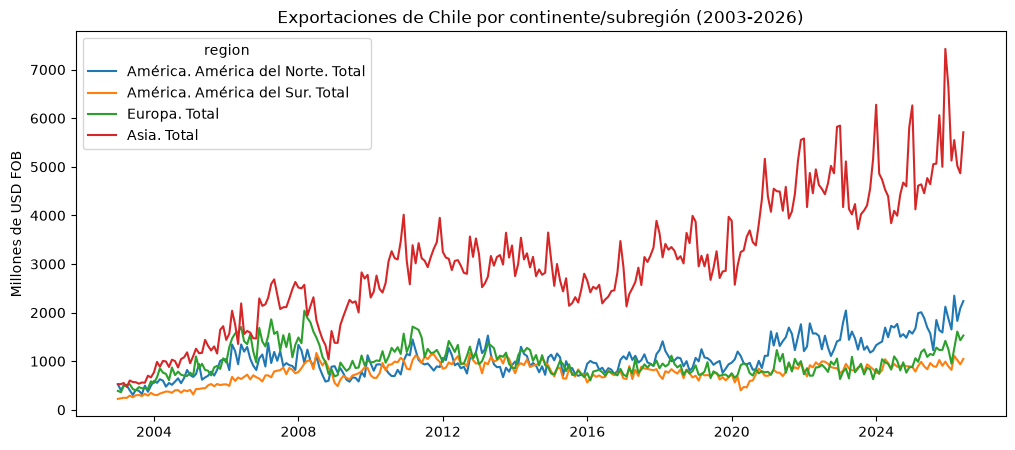

In [5]:
plt.figure(figsize=(12, 5))
sns.lineplot(
    data=totales_continentes,
    x='periodo',
    y='exportaciones_musd',
    hue='region'
)
plt.title('Exportaciones de Chile por continente/subregión (2003-2026)')
plt.ylabel('Millones de USD FOB')
plt.xlabel('')
plt.show

In [6]:
# Comparamos el cambio de régimen pre/post 2020
totales_continentes['periodo'] = totales_continentes['periodo'].dt.year
(totales_continentes
    .groupby(['region', totales_continentes['periodo'] >= 2020])
    ['exportaciones_musd']
    .mean()
    .unstack()
)

periodo,False,True
region,,
América. América del Norte. Total,904.725964,1476.151603
América. América del Sur. Total,741.335473,841.335510
Asia. Total,2394.948086,4612.416752
Europa. Total,1003.641957,942.602075
